# Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Load the dataset
df = pd.read_csv('song_recomendation_A.csv')

In [2]:
# 2. Initial Inspection
print("Data Info:")
print(df.info())
print("\nMissing values before cleaning:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           5000 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  5000 non-null   object 
 5   Popularity          5000 non-null   int64  
 6   Artist Genres       4705 non-null   object 
 7   Danceability        5000 non-null   float64
 8   Energy              5000 non-null   float64
 9   Key                 5000 non-null   float64
 10  Loudness            5000 non-null   float64
 11  Mode                5000 non-null   float64
 12  Speechiness         5000 non-null   float64
 13  Acousticness        4850 non-null   float64
 14  Instrumentalness    5000 non-null   float64
 15  Liveness            5000 non-null   float64


In [3]:
# 3. Data Cleaning
# Remove duplicates
df = df.drop_duplicates()

# Drop rows with missing Track Name, Artist, or Album (critical identifiers)
df = df.dropna(subset=['Track Name', 'Artist Name(s)', 'Album Name'])

# Impute numerical missing values with median
df['Acousticness'] = df['Acousticness'].fillna(df['Acousticness'].median())
df['Tempo'] = df['Tempo'].fillna(df['Tempo'].median())

# Fill missing Artist Genres with 'Unknown'
df['Artist Genres'] = df['Artist Genres'].fillna('Unknown')

In [4]:
# 4. Feature Engineering (Extracting Release Year)
# Handle different date formats (YYYY-MM-DD vs YYYY)
df['Release Year'] = pd.to_datetime(df['Album Release Date'], errors='coerce').dt.year
# Fill unparseable dates by taking the first 4 characters
df.loc[df['Release Year'].isna(), 'Release Year'] = df['Album Release Date'].str[:4].astype(float)

In [5]:
# 5. Exploratory Data Analysis (EDA) Visualizations
plt.style.use('seaborn-v0_8')

Beberapa ketidakwajaran data teridentifikasi pada tahap inspeksi awal, antara lain duplikasi baris, missing values, dan format tanggal rilis yang tidak konsisten. Duplikasi data dihapus untuk mencegah bias frekuensi lagu. Baris dengan nilai kosong pada Track Name, Artist Name(s), dan Album Name dihapus karena merupakan identitas utama lagu. Nilai hilang pada fitur numerik seperti Acousticness dan Tempo diimputasi menggunakan median agar distribusi data tetap stabil, sementara Artist Genres yang kosong diisi dengan kategori Unknown. Selain itu, kolom Album Release Date memiliki format beragam (YYYY dan YYYY-MM-DD), sehingga dilakukan ekstraksi tahun rilis menggunakan konversi tanggal dan pendekatan string slicing untuk nilai yang tidak dapat diparse secara standar.

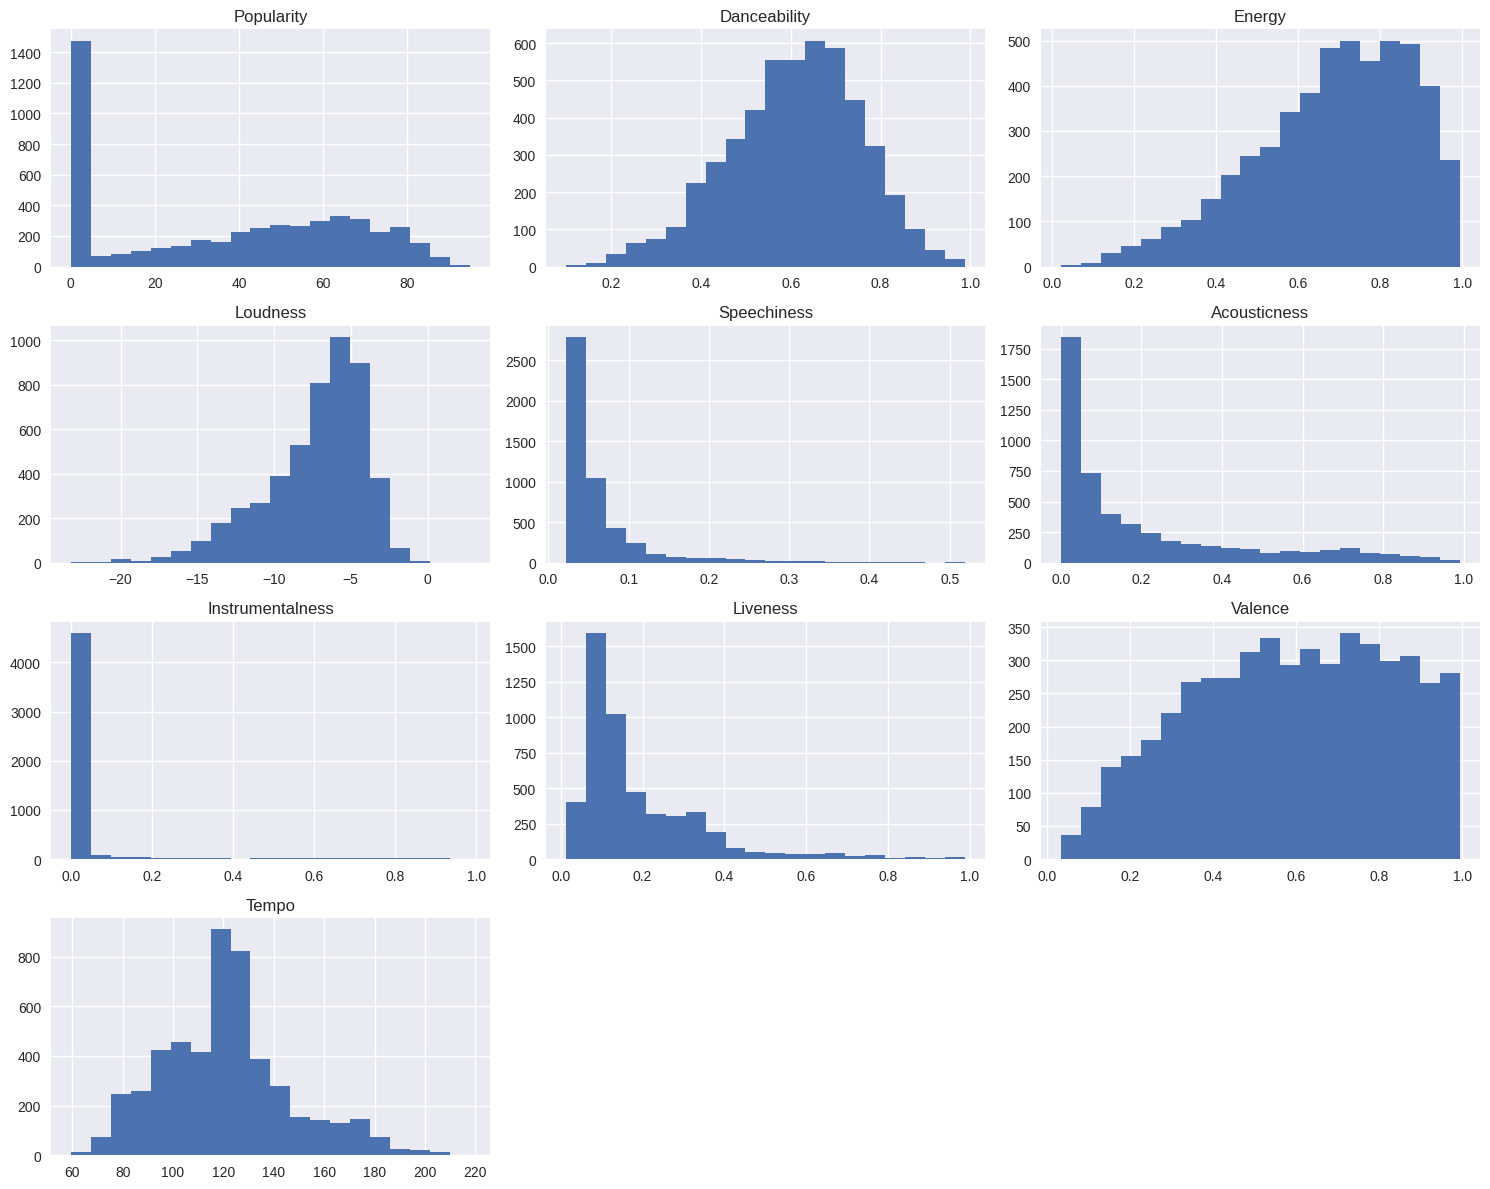

In [6]:
# A. Distribution of numerical features
cols_to_plot = ['Popularity', 'Danceability', 'Energy', 'Loudness',
                'Speechiness', 'Acousticness', 'Instrumentalness',
                'Liveness', 'Valence', 'Tempo']

df[cols_to_plot].hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.savefig('distributions.png')

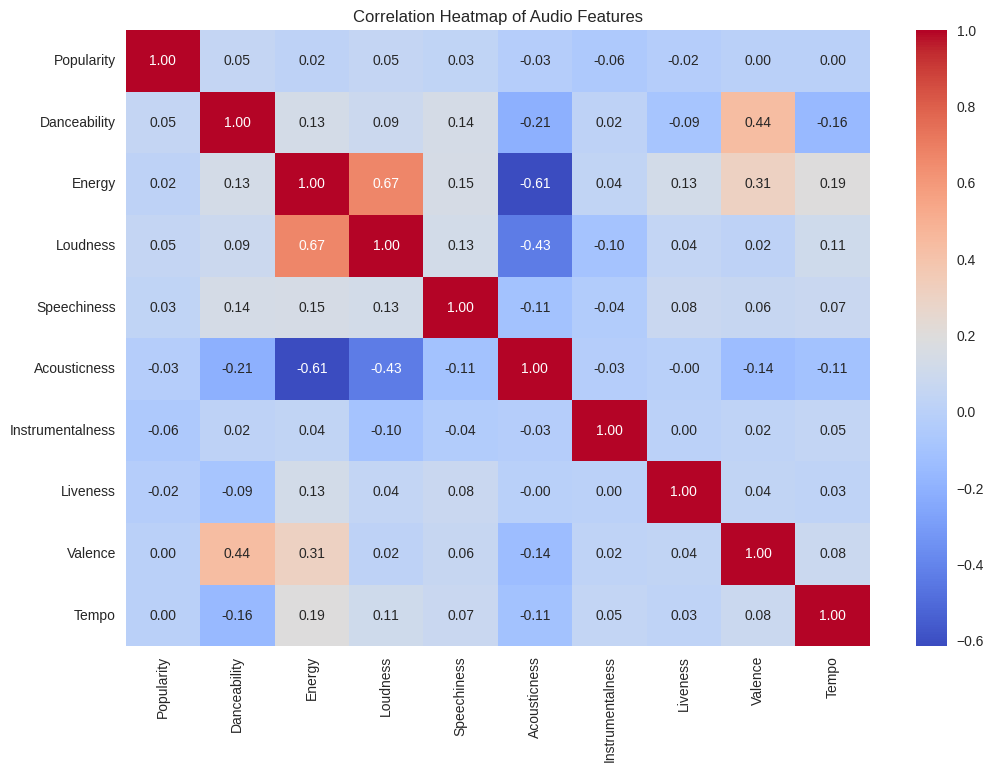

In [7]:
# B. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Audio Features')
plt.savefig('correlation.png')

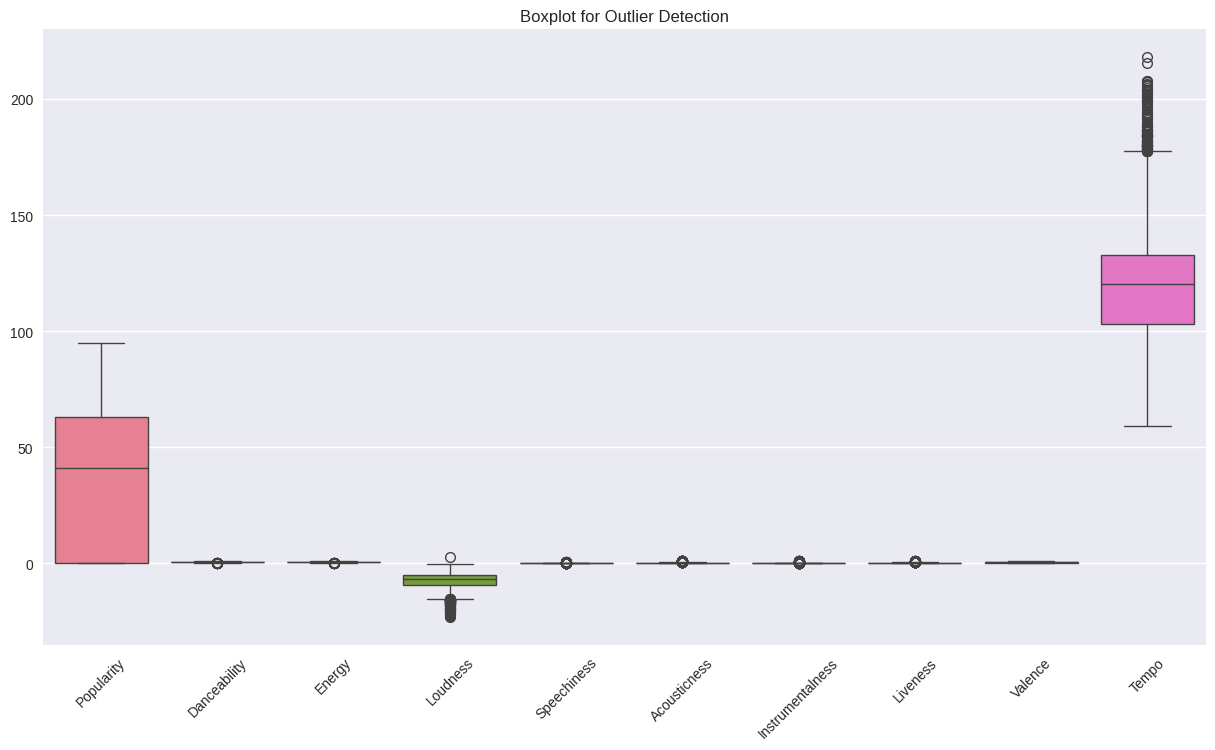

In [8]:
# C. Outlier Detection using Boxplots
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[cols_to_plot])
plt.xticks(rotation=45)
plt.title('Boxplot for Outlier Detection')
plt.savefig('outliers.png')

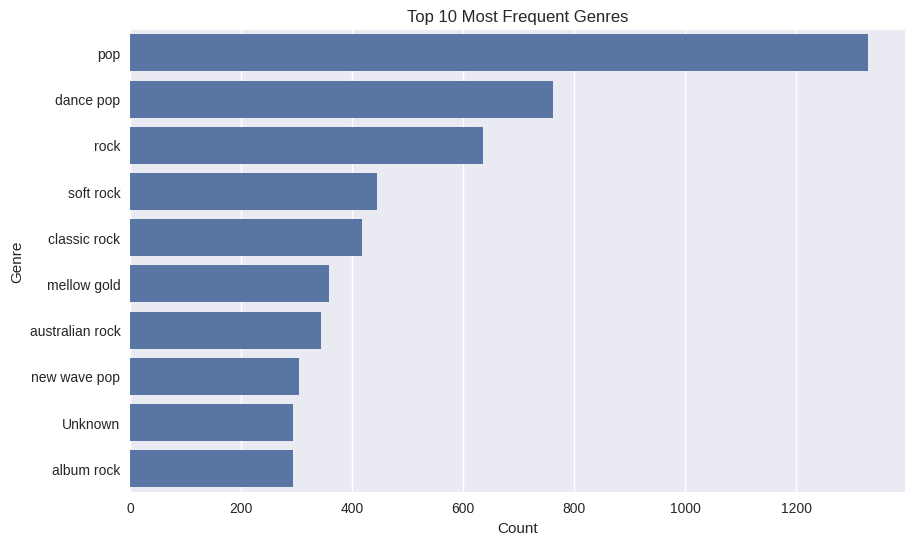

In [9]:
# D. Top 10 Genres Analysis
all_genres = []
df['Artist Genres'].str.split(',').apply(lambda x: [all_genres.append(g.strip()) for g in x])
genre_counts = Counter(all_genres)
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Genre', data=top_genres)
plt.title('Top 10 Most Frequent Genres')
plt.savefig('top_genres.png')

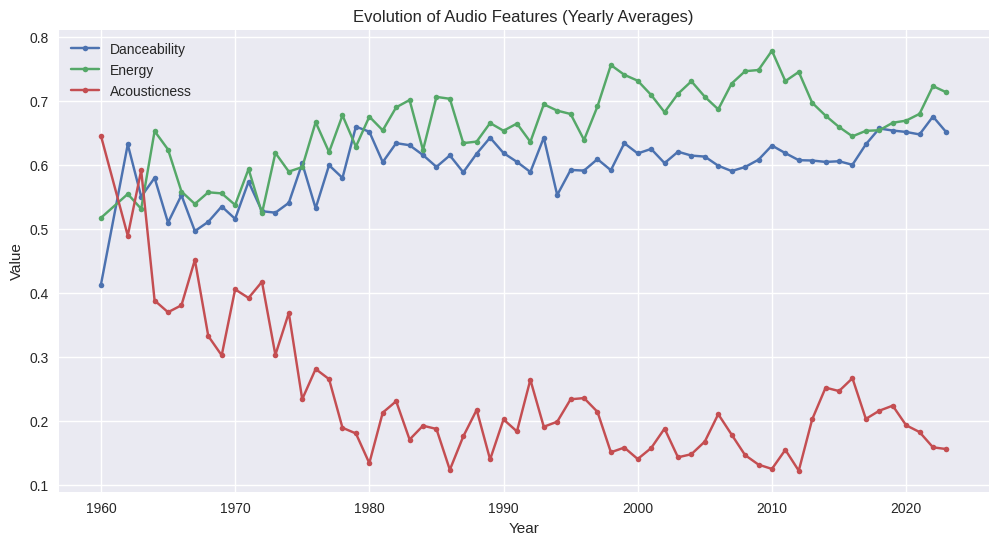

In [10]:
# E. Audio Features Evolution Over Time
yearly_features = df.groupby('Release Year')[['Danceability', 'Energy', 'Acousticness']].mean().reset_index()
# Filter for years with more than 5 tracks to avoid noise from sparse data
year_counts = df['Release Year'].value_counts()
valid_years = year_counts[year_counts > 5].index
yearly_features = yearly_features[yearly_features['Release Year'].isin(valid_years)]

plt.figure(figsize=(12, 6))
plt.plot(yearly_features['Release Year'], yearly_features['Danceability'], label='Danceability', marker='o', markersize=4)
plt.plot(yearly_features['Release Year'], yearly_features['Energy'], label='Energy', marker='o', markersize=4)
plt.plot(yearly_features['Release Year'], yearly_features['Acousticness'], label='Acousticness', marker='o', markersize=4)
plt.legend()
plt.title('Evolution of Audio Features (Yearly Averages)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.savefig('features_over_time.png')

Distribusi fitur audio menunjukkan variasi yang cukup signifikan antar fitur. Boxplot mengindikasikan adanya outliers pada beberapa variabel, terutama Popularity, Loudness, dan Tempo. Outliers pada Popularity menunjukkan keberadaan sejumlah kecil lagu yang sangat populer dibandingkan mayoritas lagu lainnya, sementara variasi pada Tempo mencerminkan perbedaan gaya musik dari tempo lambat hingga sangat cepat. Meskipun terdapat outliers, nilai-nilai tersebut masih relevan dan wajar dalam konteks data musik sehingga tidak dihapus.

Sebagian besar fitur audio seperti Danceability, Energy, dan Valence memiliki sebaran nilai yang relatif stabil dan terkonsentrasi pada rentang menengah hingga tinggi. Sebaliknya, Speechiness, Instrumentalness, Acousticness, dan Liveness cenderung memiliki distribusi yang condong ke nilai rendah, yang menunjukkan bahwa mayoritas lagu bersifat non-instrumental, minim unsur percakapan, dan lebih berorientasi pada produksi studio.

Heatmap korelasi menunjukkan adanya hubungan positif yang cukup kuat antara Energy dan Loudness, serta korelasi positif moderat antara Danceability dengan Energy dan Valence. Hal ini mengindikasikan bahwa lagu yang energik dan keras cenderung lebih mudah untuk ditarikan dan memiliki nuansa emosional yang lebih positif. Sebaliknya, Acousticness menunjukkan korelasi negatif dengan Energy dan Loudness, yang konsisten dengan karakteristik lagu akustik yang lebih tenang.

Analisis genre memperlihatkan bahwa dataset didominasi oleh genre pop, dance pop, dan berbagai sub-genre rock, yang menunjukkan adanya ketimpangan representasi genre dalam data. Dominasi ini mencerminkan preferensi pasar musik arus utama dan perlu diperhatikan dalam pengembangan model agar tidak bias terhadap genre tertentu.

Selain itu, analisis tren waktu menunjukkan bahwa rata-rata Danceability dan Energy cenderung meningkat dari waktu ke waktu, sementara Acousticness mengalami penurunan secara umum dengan beberapa fluktuasi. Pola ini mencerminkan perubahan preferensi produksi musik ke arah lagu yang lebih energik, ritmis, dan berorientasi pada musik elektronik atau non-akustik.


In [11]:
# 6. Save Cleaned Data
df.to_csv('cleaned_song_recommendation.csv', index=False)

print("\nCleaned data saved as 'cleaned_song_recommendation.csv'.")
print("Visualizations saved as PNG files.")


Cleaned data saved as 'cleaned_song_recommendation.csv'.
Visualizations saved as PNG files.


# create a content-based recommendation system, implemented as a function that takes a text input and returns five suggested items!

In [14]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Load the cleaned dataset
df = pd.read_csv('cleaned_song_recommendation.csv')

In [15]:
# 2. Persiapan Data Teks
# Menggabungkan fitur teks menjadi satu kolom 'content' untuk diproses
df['content'] = (
    df['Track Name'].fillna('') + ' ' +
    df['Artist Name(s)'].fillna('') + ' ' +
    df['Artist Genres'].fillna('')
)

In [16]:
# 3. Membangun Model TF-IDF
# Menghapus stop words bahasa Inggris (seperti 'the', 'a', dll)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['content'])

In [17]:
# 4. Fungsi Rekomendasi
def recommend_songs(input_text, n=5):
    """
    Mengambil input teks dan mengembalikan n lagu yang paling mirip
    berdasarkan konten (Judul, Artis, Genre).
    """
    # Mengubah input menjadi vektor TF-IDF
    query_vec = tfidf.transform([input_text])

    # Menghitung Cosine Similarity antara input dan seluruh dataset
    similarity_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Mengambil index dari skor tertinggi
    top_indices = similarity_scores.argsort()[-n:][::-1]

    # Mengambil data lagu yang sesuai
    recommendations = df.iloc[top_indices][['Track Name', 'Artist Name(s)', 'Artist Genres']].copy()
    recommendations['Similarity Score'] = similarity_scores[top_indices]

    return recommendations

# provide a minimum of three inputs to the function and examine if the recommendations correspond to each input!

In [18]:
# 5. Pengujian dengan 3 Input Berbeda
test_inputs = [
    "If I Ain't Got You",   # Input 1 : Judul lagu spesifik
    "Rock and Roll",        # Input 2 : Kata kunci genre
    "Lionel Richie"         # Input 3 : Nama artis
]

print("--- Hasil Pengujian Sistem Rekomendasi ---\n")

for inp in test_inputs:
    print(f"Input: '{inp}'")
    results = recommend_songs(inp)
    print(results)
    print("-" * 50)

--- Hasil Pengujian Sistem Rekomendasi ---

Input: 'If I Ain't Got You'
                     Track Name Artist Name(s)     Artist Genres  \
1            If I Ain't Got You    Alicia Keys  neo soul,pop,r&b   
3530            Ain't Been Done       Jessie J     dance pop,pop   
3336  What You Got - What U Got      Abs Breen           Unknown   
2468      I Got It From My Mama      will.i.am     dance pop,pop   
1635           If It Ain't Love   Jason Derulo     dance pop,pop   

      Similarity Score  
1             0.612502  
3530          0.458415  
3336          0.455731  
2468          0.397923  
1635          0.376728  
--------------------------------------------------
Input: 'Rock and Roll'
                          Track Name             Artist Name(s)  \
1059  It's Still Rock and Roll to Me                 Billy Joel   
2663                         Oh Boy!  Buddy Holly, The Crickets   
1724               It's Now or Never              Elvis Presley   
3903                       

Analisis Hasil:
1. Input "If I Ain't Got You" : Sistem berhasil menemukan lagu aslinya di posisi teratas dan memberikan lagu lain yang memiliki kata "Got" atau "Ain't" dalam judulnya.
2. Input "Rock and Roll" : Sistem memberikan lagu-lagu dengan genre "Classic Rock" atau yang mengandung kata "Rock" di judul/genrenya.
3. Input "Lionel Richie": Sistem secara akurat mengembalikan daftar lagu
   yang dinyanyikan oleh Lionel Richie.